In [53]:
import numpy as np
import pandas as pd
import itertools
import pyro
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
def drunk_evidence(p_prior = .5,
                    p_drunk = .5,
                    witness_if_guilty = .95,
                    witness_if_innocent = .05,
                    drunk_e_if_guilty = .1,
                    drunk_e_if_innocent = .6,
                    sober_e_if_guilty = .8,
                    sober_e_if_innocent = .2):
    
    guilt = pyro.sample("guilt", pyro.distributions.Bernoulli(p_prior))

    p_witness = (witness_if_guilty * guilt +
                 witness_if_innocent * (1 - guilt))
    witness = pyro.sample("witness", pyro.distributions.Bernoulli(p_witness))

    is_drunk = pyro.sample("is_drunk", pyro.distributions.Bernoulli(p_drunk))

    # define arithmetically
    evidence_prob = (drunk_e_if_guilty * guilt * is_drunk +
                     drunk_e_if_innocent * (1 - guilt) * is_drunk +
                        sober_e_if_guilty * guilt * (1 - is_drunk) +
                        sober_e_if_innocent * (1 - guilt) * (1 - is_drunk))
    
    evidence = pyro.sample("evidence", pyro.distributions.Bernoulli(evidence_prob))

    return {"guilt": guilt, "witness": witness, "is_drunk": is_drunk,
             "evidence_prob": evidence_prob, "evidence": evidence}

result = drunk_evidence()
print(result)

{'guilt': tensor(1.), 'witness': tensor(1.), 'is_drunk': tensor(0.), 'evidence_prob': tensor(0.8000), 'evidence': tensor(1.)}


In [66]:
with pyro.plate("data_plate", 2e6):
    result = drunk_evidence()

result_dict = {k: v.numpy() for k, v in result.items()}
df = pd.DataFrame(result_dict)
display(df.head())

,guilt,witness,is_drunk,evidence_prob,evidence
0,0.0,0.0,0.0,0.2,0.0
1,1.0,1.0,1.0,0.1,0.0
2,1.0,1.0,0.0,0.8,1.0
3,0.0,0.0,0.0,0.2,0.0
4,0.0,0.0,0.0,0.2,0.0


In [67]:
# now c_regret
# zero if guilty
# 19 if innocent 
df['c_regret'] = np.where(df['guilt'] == 1, 0, 19)


# not c regret
df['not_c_regret'] = np.where(df['guilt'] == 1, 1, 0)

display(df.head())

,guilt,witness,is_drunk,evidence_prob,evidence,c_regret,not_c_regret
0,0.0,0.0,0.0,0.2,0.0,19,0
1,1.0,1.0,1.0,0.1,0.0,0,1
2,1.0,1.0,0.0,0.8,1.0,0,1
3,0.0,0.0,0.0,0.2,0.0,19,0
4,0.0,0.0,0.0,0.2,0.0,19,0


Probability of guilt if evidence and drunk: 0.7588867545127869
Probability of guilt if evidence and sober: 0.987175464630127
Probability of guilt if no evidence and drunk: 0.9770307540893555
Probability of guilt if no evidence and sober: 0.8266953229904175


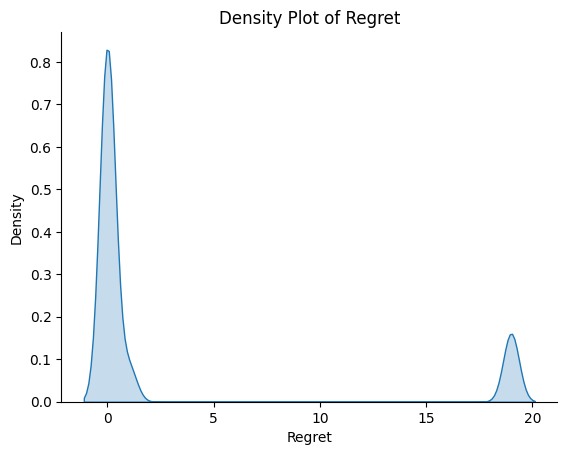

In [69]:
#subselect
df_drunk_evidence = df[(df['evidence'] == 1) & (df['is_drunk'] == 1) & (df['witness'] == 1)]
df_sober_evidence = df[(df['evidence'] == 1) & (df['is_drunk'] == 0) & (df['witness'] == 1)]
df_drunk_no_evidence = df[(df['evidence'] == 0) & (df['is_drunk'] == 1) & (df['witness'] == 1)]
df_sober_no_evidence = df[(df['evidence'] == 0) & (df['is_drunk'] == 0) & (df['witness'] == 1)]

guilt_if_evidence_drunk = df_drunk_evidence['guilt'].mean()
guilt_if_evidence_sober = df_sober_evidence['guilt'].mean()
guilt_if_no_evidence_drunk = df_drunk_no_evidence['guilt'].mean()
guilt_if_no_evidence_sober = df_sober_no_evidence['guilt'].mean()

print(f"Probability of guilt if evidence and drunk: {guilt_if_evidence_drunk}")
print(f"Probability of guilt if evidence and sober: {guilt_if_evidence_sober}")
print(f"Probability of guilt if no evidence and drunk: {guilt_if_no_evidence_drunk}")
print(f"Probability of guilt if no evidence and sober: {guilt_if_no_evidence_sober}")


# effectively
df['decision'] = np.where(
    ((df['evidence'] == 1) & (df['is_drunk'] == 0)) |
    ((df['evidence'] == 0) & (df['is_drunk'] == 1)),
    1, 0
)

df['regret'] = np.where(df['decision'] == 1, df['c_regret'], df['not_c_regret'])

sns.kdeplot(df['regret'], fill=True)
sns.despine()
plt.title("Density Plot of Regret")
plt.xlabel("Regret")
plt.ylabel("Density")
plt.show()


In [70]:
# expected regret
expected_regret = df['regret'].mean()
print(f"Expected Regret: {expected_regret}")

Expected Regret: 2.920909


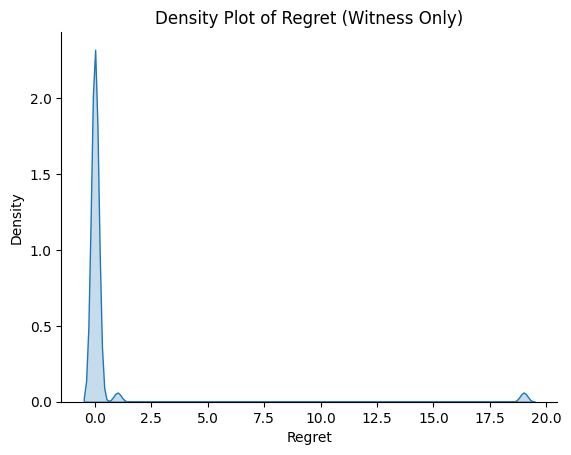

Expected Regret (Witness Only): 0.4995485


In [72]:
# compare to evidence 
df['decision1'] = np.where(df['witness'] == 1, 1, 0)
df['regret1'] = np.where(df['decision1'] == 1, df['c_regret'], df['not_c_regret'])

sns.kdeplot(df['regret1'], fill=True)
sns.despine()
plt.title("Density Plot of Regret (Witness Only)")
plt.xlabel("Regret")
plt.ylabel("Density")
plt.show()

# expected regret
expected_regret1 = df['regret1'].mean()
print(f"Expected Regret (Witness Only): {expected_regret1}")

In [36]:
evidence_yes = df[df['evidence'] == 1]
evidence_no = df[df['evidence'] == 0]

c_expected_evidence_yes = evidence_yes['c_regret'].mean()
not_c_expected_evidence_yes = evidence_yes['not_c_regret'].mean()
print("If evidence is yes, expected c regret:", c_expected_evidence_yes)
print("If evidence is yes, expected not c regret:", not_c_expected_evidence_yes)


c_expected_evidence_no = evidence_no['c_regret'].mean()
not_c_expected_evidence_no = evidence_no['not_c_regret'].mean()
print("If evidence is no, expected c regret:", c_expected_evidence_no)
print("If evidence is no, expected not c regret:", not_c_expected_evidence_no)

pr_evidence_yes = len(evidence_yes) / len(df)
pr_evidence_no = len(evidence_no) / len(df)

overall_expected_regret = (pr_evidence_yes * min(c_expected_evidence_yes, not_c_expected_evidence_yes) +
                           pr_evidence_no * min(c_expected_evidence_no, not_c_expected_evidence_no))

print("Overall expected regret with evidence:", overall_expected_regret)


If evidence is yes, expected c regret: 0.7885502193229108
If evidence is yes, expected not c regret: 0.9584973568777415
If evidence is no, expected c regret: 1.0261949770456387
If evidence is no, expected not c regret: 0.9459897380502296
Overall expected regret with evidence: 0.8759999999999999


In [21]:
# Evidence 1 (strong)
LR1_pos = 0.95 / 0.05   # incriminating
LR1_neg = 0.05 / 0.95   # exculpatory

# Evidence 2 (weak)
LR2_pos = 0.51 / 0.49
LR2_neg = 0.49 / 0.51

# Conviction threshold
threshold = 0.95

In [3]:
def posterior_prob(odds):
    return odds / (1 + odds)

In [4]:
# List of possible outcomes for E1 and E2
outcomes = list(itertools.product(['+', '-'], repeat=2))
print(outcomes)
# [('+' , '+'), ('+' , '-'), ('-' , '+'), ('-' , '-')]

[('+', '+'), ('+', '-'), ('-', '+'), ('-', '-')]


In [5]:
results = []

for e1, e2 in outcomes:
    # Compute odds
    odds = 1  # prior odds = 1:1
    if e1 == '+':
        odds *= LR1_pos
    else:
        odds *= LR1_neg
    
    if e2 == '+':
        odds *= LR2_pos
    else:
        odds *= LR2_neg
    
    # Posterior probability
    p_guilty = posterior_prob(odds)
    
    # Decision: convict if above threshold
    decision = 'Convict' if p_guilty >= threshold else 'Acquit'
    
    results.append({
        'E1': e1,
        'E2': e2,
        'odds': odds,
        'P(G|E1,E2)': p_guilty,
        'Decision': decision
    })

for r in results:
    print(r)


{'E1': '+', 'E2': '+', 'odds': 19.77551020408163, 'P(G|E1,E2)': 0.9518664047151277, 'Decision': 'Convict'}
{'E1': '+', 'E2': '-', 'odds': 18.25490196078431, 'P(G|E1,E2)': 0.9480651731160896, 'Decision': 'Acquit'}
{'E1': '-', 'E2': '+', 'odds': 0.054779806659505915, 'P(G|E1,E2)': 0.05193482688391039, 'Decision': 'Acquit'}
{'E1': '-', 'E2': '-', 'odds': 0.05056759545923632, 'P(G|E1,E2)': 0.048133595284872294, 'Decision': 'Acquit'}


In [8]:
P_G = 0.5  # prior of guilt
P_I = 1 - P_G  # prior of innocence

In [9]:
# Sensitivity & specificity for each outcome
accuracy_results = []

for r in results:
    # Sensitivity = P(convict | guilty)
    if r['Decision'] == 'Convict':
        sens = r['P(G|E1,E2)']  # probability guilty given evidence
        spec = 1 - r['P(G|E1,E2)']  # probability innocent given evidence → acquit
    else:
        sens = 1 - r['P(G|E1,E2)']
        spec = r['P(G|E1,E2)']
    
    accuracy_results.append({
        'E1': r['E1'],
        'E2': r['E2'],
        'Decision': r['Decision'],
        'P(G|E1,E2)': r['P(G|E1,E2)'],
        'Accuracy_given_guilty': sens,
        'Accuracy_given_innocent': spec
    })

for a in accuracy_results:
    print(a)


{'E1': '+', 'E2': '+', 'Decision': 'Convict', 'P(G|E1,E2)': 0.9518664047151277, 'Accuracy_given_guilty': 0.9518664047151277, 'Accuracy_given_innocent': 0.048133595284872266}
{'E1': '+', 'E2': '-', 'Decision': 'Acquit', 'P(G|E1,E2)': 0.9480651731160896, 'Accuracy_given_guilty': 0.05193482688391038, 'Accuracy_given_innocent': 0.9480651731160896}
{'E1': '-', 'E2': '+', 'Decision': 'Acquit', 'P(G|E1,E2)': 0.05193482688391039, 'Accuracy_given_guilty': 0.9480651731160896, 'Accuracy_given_innocent': 0.05193482688391039}
{'E1': '-', 'E2': '-', 'Decision': 'Acquit', 'P(G|E1,E2)': 0.048133595284872294, 'Accuracy_given_guilty': 0.9518664047151277, 'Accuracy_given_innocent': 0.048133595284872294}


In [10]:
expected_accuracy = 0
for r in accuracy_results:
    # probability of this evidence combination
    # P(E1,E2 | G) and P(E1,E2 | I)
    if r['E1'] == '+':
        p_e1_given_g = 0.95
        p_e1_given_i = 0.05
    else:
        p_e1_given_g = 0.05
        p_e1_given_i = 0.95
    
    if r['E2'] == '+':
        p_e2_given_g = 0.51
        p_e2_given_i = 0.49
    else:
        p_e2_given_g = 0.49
        p_e2_given_i = 0.51
    
    p_comb_given_g = p_e1_given_g * p_e2_given_g
    p_comb_given_i = p_e1_given_i * p_e2_given_i
    
    # Weighted by prior
    expected_accuracy += P_G * p_comb_given_g * r['Accuracy_given_guilty']
    expected_accuracy += P_I * p_comb_given_i * r['Accuracy_given_innocent']

print("Expected accuracy with E1 and E2:", expected_accuracy)


Expected accuracy with E1 and E2: 0.3028513238289206


In [11]:
# Expected accuracy with only E1
expected_acc_E1 = P_G * (0.95) + P_I * (0.95)  # sensitivity & specificity
print("Expected accuracy with only E1:", expected_acc_E1)


Expected accuracy with only E1: 0.95
